# Generalisation & Split Strategy Comparison

**Purpose:** Compare how the Split 2-selected model family behaves under the repository's different split protocols while keeping the main claim anchored to the Notebook 01 headline result.

This notebook **refits** the selected family on each split. It does not reuse trained headline artifacts, but it does reuse the same matched-recall operating-point policy so thresholded metrics remain comparable to Notebook 01.


In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import *
from ml.notebooks.modeling_pipeline import load_model_pack, fit_model_family_on_split

PACKS = {
    'baseline': load_model_pack('baseline', artifact='selection', seed=RANDOM_SEED),
    'ebpf': load_model_pack('ebpf', artifact='selection', seed=RANDOM_SEED),
}
print('[*] Loaded Split 2 selection artifacts from Notebook 01')


BASELINE_COLOR = "#4C78A8"
EBPF_COLOR = "#F58518"
NEUTRAL_COLOR = "#9AA1A9"

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#6B7280',
    'axes.labelcolor': '#111827',
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#374151',
    'ytick.color': '#374151',
    'grid.color': '#D7DBDF',
    'grid.linestyle': '--',
    'grid.alpha': 0.35,
    'legend.frameon': False,
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})

def savefig(fig, path, dpi=180):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')


[*] Loaded Split 2 selection artifacts from Notebook 01


## Experiment 1: Cross-split refits with the selected Notebook 01 model family

The family choice and feature list come from Split 2 selection, but each split is retrained from scratch. Thresholds use the same validation-defined matched-recall target stored by Notebook 01's headline artifacts.


In [2]:
headline_policy = {
    fs: load_model_pack(fs, artifact='headline', seed=RANDOM_SEED)
    for fs in ['baseline', 'ebpf']
}
headline_target_recall = min(
    pack.get('target_recall')
    for pack in headline_policy.values()
    if pack.get('target_recall') is not None
)
print(f'[*] Using headline matched-recall target: {headline_target_recall:.4f}')

split_map = {
    'split1_group_strat': {
        'role': 'leakage_diagnostic',
        'baseline_dir': SPLITS_1_BASELINE,
        'ebpf_dir': SPLITS_1_EBPF,
        'test_file': 'test.parquet',
    },
    'split2_balanced_quota': {
        'role': 'model_selection_context',
        'baseline_dir': SPLITS_2_BASELINE,
        'ebpf_dir': SPLITS_2_EBPF,
        'test_file': 'test.parquet',
    },
    'split3_train_resampled': {
        'role': 'resampled_training',
        'baseline_dir': SPLITS_3_BASELINE,
        'ebpf_dir': SPLITS_3_EBPF,
        'test_file': 'test.parquet',
    },
    'split4_balanced': {
        'role': 'balanced_support',
        'baseline_dir': SPLITS_4_BASELINE,
        'ebpf_dir': SPLITS_4_EBPF,
        'test_file': 'test_balanced.parquet',
    },
    'split4_realistic': {
        'role': 'headline_generalization',
        'baseline_dir': SPLITS_4_BASELINE,
        'ebpf_dir': SPLITS_4_EBPF,
        'test_file': 'test_realistic.parquet',
    },
}

rows = []
for fs in ['baseline', 'ebpf']:
    feat = PACKS[fs]['features']
    model_name = PACKS[fs]['selected_model_name']
    for split_name, meta in split_map.items():
        d = meta['baseline_dir'] if fs == 'baseline' else meta['ebpf_dir']
        if not Path(d).exists():
            continue
        result = fit_model_family_on_split(
            Path(d),
            feature_list=feat,
            model_name=model_name,
            test_file=meta['test_file'],
            seed=RANDOM_SEED,
            threshold_mode='recall',
            target_recall=headline_target_recall,
        )
        rows.append({
            'feature_set': fs,
            'model': model_name,
            'split': split_name,
            'role': meta['role'],
            'threshold_mode': 'matched_recall',
            'target_recall': headline_target_recall,
            'train_f1': result['train_metrics']['f1'],
            'val_f1': result['val_metrics']['f1'],
            'test_f1': result['test_metrics']['f1'],
            'train_auc': result['train_metrics']['roc_auc'],
            'val_auc': result['val_metrics']['roc_auc'],
            'test_auc': result['test_metrics']['roc_auc'],
            'test_precision': result['test_metrics']['precision'],
            'test_recall': result['test_metrics']['recall'],
            'test_fpr': result['test_metrics']['fpr'],
            'gap_auc_train_test': (result['train_metrics']['roc_auc'] or 0) - (result['test_metrics']['roc_auc'] or 0),
            'gap_f1_train_test': result['train_metrics']['f1'] - result['test_metrics']['f1'],
        })

res_df = pd.DataFrame(rows)
role_order = {
    'headline_generalization': 0,
    'balanced_support': 1,
    'model_selection_context': 2,
    'resampled_training': 3,
    'leakage_diagnostic': 4,
}
if not res_df.empty:
    res_df = res_df.assign(_ord=res_df['role'].map(role_order)).sort_values(
        ['_ord', 'split', 'feature_set']
    ).drop(columns=['_ord']).reset_index(drop=True)
    print(res_df.to_string(index=False, float_format='{:.4f}'.format))
    headline = res_df[res_df['split'] == 'split4_realistic']
    if not headline.empty:
        print('\nHeadline rows (Split 4 realistic):')
        print(headline.to_string(index=False, float_format='{:.4f}'.format))

res_df.to_csv(REPORTS_DIR / f'generalization_comparison_seed{RANDOM_SEED}.csv', index=False)


[*] Using headline matched-recall target: 0.5810
feature_set        model                  split                    role threshold_mode  target_recall  train_f1  val_f1  test_f1  train_auc  val_auc  test_auc  test_precision  test_recall  test_fpr  gap_auc_train_test  gap_f1_train_test
   baseline hgb_balanced       split4_realistic headline_generalization matched_recall         0.5810    0.9392  0.1939   0.5151     1.0000   0.9721    0.9202          0.8581       0.3680    0.0506              0.0798             0.4241
       ebpf hgb_balanced       split4_realistic headline_generalization matched_recall         0.5810    0.9446  0.2005   0.5144     1.0000   0.9704    0.7115          0.8572       0.3675    0.0509              0.2885             0.4302
   baseline hgb_balanced        split4_balanced        balanced_support matched_recall         0.5810    0.9392  0.1939   0.5455     1.0000   0.9721    0.9219          1.0000       0.3750    0.0000              0.0781             0.3937
   

## Experiment 2: Visual comparison of headline vs supporting splits


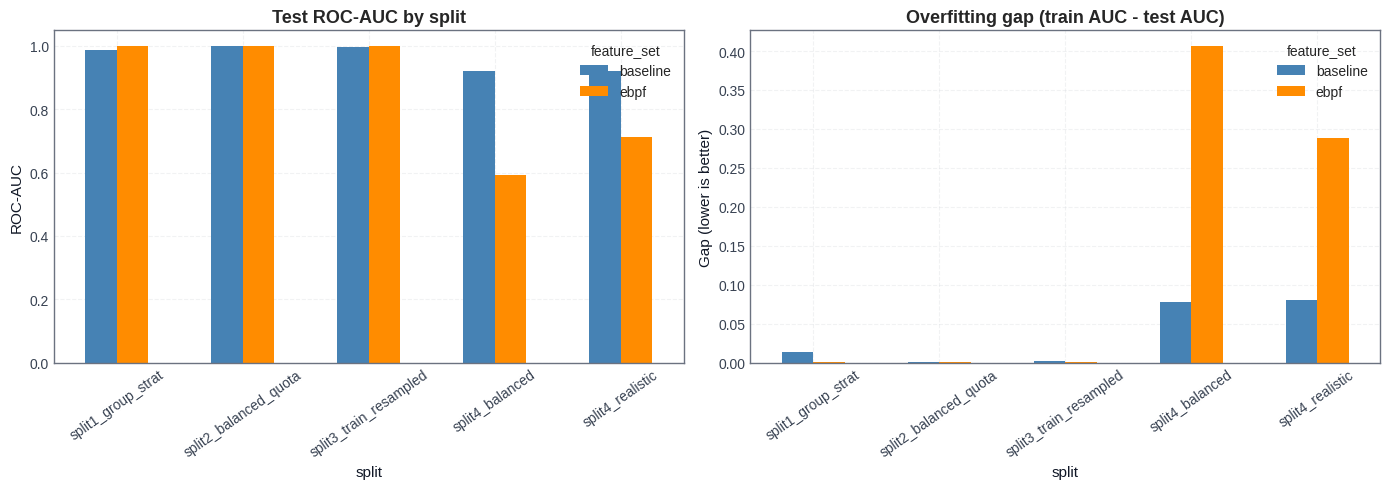

In [3]:
if not res_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    p1 = res_df.pivot_table(index='split', columns='feature_set', values='test_auc')
    p1.plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'])
    axes[0].set_title('Test ROC-AUC by split')
    axes[0].set_ylabel('ROC-AUC')
    axes[0].tick_params(axis='x', rotation=35)

    p2 = res_df.pivot_table(index='split', columns='feature_set', values='gap_auc_train_test')
    p2.plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'])
    axes[1].set_title('Overfitting gap (train AUC - test AUC)')
    axes[1].set_ylabel('Gap (lower is better)')
    axes[1].tick_params(axis='x', rotation=35)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f'generalization_plots_seed{RANDOM_SEED}.png', dpi=150)
    plt.show()


## Generalisation profile across evaluation protocols

The central question here is not only which feature set wins, but how sensitive each feature set is to protocol choice, class balance, and leakage control.

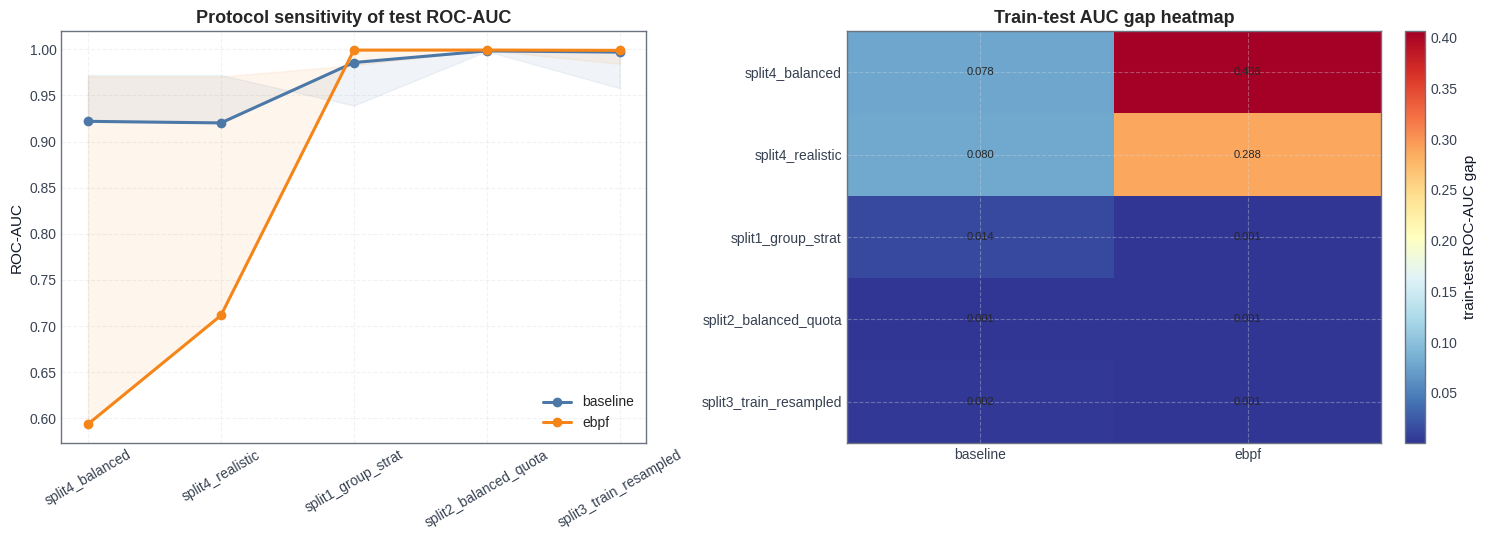

[+] Saved generalisation profile: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/generalization_profile_seed42.png


In [4]:
if not res_df.empty:
    plot_df = res_df.copy()
    split_order = plot_df[['split', 'role']].drop_duplicates().sort_values('role')['split'].tolist()
    plot_df['split'] = pd.Categorical(plot_df['split'], split_order, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for fs_name, color in [('baseline', BASELINE_COLOR), ('ebpf', EBPF_COLOR)]:
        subset = plot_df[plot_df['feature_set'] == fs_name].sort_values('split')
        axes[0].plot(subset['split'].astype(str), subset['test_auc'], marker='o', linewidth=2.2, color=color, label=fs_name)
        axes[0].fill_between(subset['split'].astype(str), subset['val_auc'], subset['test_auc'], color=color, alpha=0.08)
    axes[0].set_title('Protocol sensitivity of test ROC-AUC')
    axes[0].set_ylabel('ROC-AUC')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend()

    heat_df = plot_df.pivot(index='split', columns='feature_set', values='gap_auc_train_test').reindex(split_order)
    im = axes[1].imshow(heat_df.to_numpy(), aspect='auto', cmap='RdYlBu_r')
    axes[1].set_title('Train-test AUC gap heatmap')
    axes[1].set_xticks(range(len(heat_df.columns)))
    axes[1].set_xticklabels(heat_df.columns)
    axes[1].set_yticks(range(len(heat_df.index)))
    axes[1].set_yticklabels(heat_df.index)
    for i, idx in enumerate(heat_df.index):
        for j, col in enumerate(heat_df.columns):
            val = heat_df.loc[idx, col]
            axes[1].text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label='train-test ROC-AUC gap')

    plt.tight_layout()
    out = REPORTS_DIR / f'generalization_profile_seed{RANDOM_SEED}.png'
    savefig(fig, out)
    plt.show()
    print(f'[+] Saved generalisation profile: {out}')


## Experiment 3: Split 5 robustness metadata summary


In [5]:
# Split 5 robustness summary from Notebook 00 outputs
for fs, kdir in [('baseline', SPLITS_5_BASELINE), ('ebpf', SPLITS_5_EBPF)]:
    p = kdir / 'folds_meta.json'
    if not p.exists():
        legacy = kdir / 'kfold_report.json'
        p = legacy if legacy.exists() else p
    if not p.exists():
        print(f'[!] Missing Split 5 metadata: {kdir}')
        continue
    rep = json.loads(p.read_text())
    folds = rep.get('folds', [])
    if not folds:
        print(f'[!] Empty Split 5 metadata: {p}')
        continue
    tr = [f['train_rows'] for f in folds]
    te = [f['test_rows'] for f in folds]
    ta = [f['test_attacks'] for f in folds]
    unseen = sum(1 for f in folds if f.get('unseen_in_train'))
    print(f"\n[*] {fs} split5")
    print(
        f"  mode={rep.get('split_mode')} n_splits={rep.get('n_splits')} "
        f"repeats={rep.get('n_repeats')} total_folds={rep.get('total_folds')}"
    )
    print(f"  train rows: mean={np.mean(tr):,.0f} min={np.min(tr):,} max={np.max(tr):,}")
    print(f"  test rows : mean={np.mean(te):,.0f} min={np.min(te):,} max={np.max(te):,}")
    print(f"  test attacks: mean={np.mean(ta):,.0f} min={np.min(ta):,} max={np.max(ta):,}")
    print(f"  folds with unseen-in-train families: {unseen}")



[*] baseline split5
  mode=kfold n_splits=5 repeats=3 total_folds=15
  train rows: mean=1,692,189 min=1,197,254 max=1,884,738
  test rows : mean=423,047 min=230,498 max=917,982
  test attacks: mean=89,472 min=0 max=445,807
  folds with unseen-in-train families: 9

[*] ebpf split5
  mode=kfold n_splits=5 repeats=3 total_folds=15
  train rows: mean=1,692,189 min=1,197,254 max=1,884,738
  test rows : mean=423,047 min=230,498 max=917,982
  test attacks: mean=89,472 min=0 max=445,807
  folds with unseen-in-train families: 9
